# Modelo 3: SARIMAX para Predicción de Gastos

**SARIMAX** (Seasonal AutoRegressive Integrated Moving Average with eXogenous variables) es uno de los modelos estadísticos más rigurosos clásicos para series de tiempo.

A diferencia del simple ARIMA, la 'S' nos permite decirle que hay un ciclo que se repite (ej. cada 12 meses), y la 'X' nos permite incluir los *Ingresos* como variable exógena.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from pmdarima import auto_arima
import warnings

warnings.filterwarnings('ignore')

### 1. Carga y Agrupación Mensual

In [3]:
# Cargar datos
file_path = '../data/raw/db_orig.csv'
df = pd.read_csv(file_path)

# Limpieza
df['Amount'] = df['Amount'].str.replace('€', '', regex=False)
df['Amount'] = df['Amount'].str.replace('.', '', regex=False)
df['Amount'] = df['Amount'].str.replace(',', '.', regex=False)
df['Amount'] = pd.to_numeric(df['Amount'])

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Agrupar por Mes Fin
df['Month_End'] = df['Date'].dt.to_period('M').dt.to_timestamp('M')
monthly = df.groupby(['Month_End', 'Type'])['Amount'].sum().unstack(fill_value=0).reset_index()

if 'Expenses' not in monthly.columns: monthly['Expenses'] = 0
if 'Income' not in monthly.columns: monthly['Income'] = 0

# Ordenar por fecha y hacer la fecha el índice (necesario para Statsmodels)
ts_df = monthly.set_index('Month_End').sort_index()
ts_df.index.freq = 'ME'  # Asegurar frecuencia mensual (Month End)

display(ts_df.head())

Type,Expenses,Income
Month_End,,
2021-09-30,151.22,1250.62
2021-10-31,328.70,115.00
2021-11-30,258.91,270.07
2021-12-31,201.43,487.50
2022-01-31,79.02,203.99


### 2. Búsqueda Automática de los Mejores Parámetros (Auto ARIMA)
En lugar de adivinar los parámetros (p, d, q) y estacionales (P, D, Q, s), usamos *Auto ARIMA* para que busque la mejor combinación que minimice el error Akaike (AIC).

In [4]:
# Variable endógena (lo que predecimos)
y = ts_df['Expenses']

# Variable exógena (información extra que ayuda)
exog = ts_df[['Income']]

# Buscar el mejor modelo.
# m=12 porque esperamos patrones que se repiten anualmente (12 meses)
print("Buscando los mejores parámetros p,d,q y estacionales...")
auto_model = auto_arima(y,
                        X=exog,
                        seasonal=True,
                        m=12, 
                        start_p=0, start_q=0, max_p=3, max_q=3,
                        d=None, D=1, # Permitir que encuentre si necesita diferenciación
                        trace=True,
                        error_action='ignore',  
                        suppress_warnings=True, 
                        stepwise=True)

print("\nMejor modelo seleccionado:\n", auto_model.summary())

Buscando los mejores parámetros p,d,q y estacionales...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=2.51 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=605.226, Time=0.06 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=604.149, Time=1.41 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=2.03 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=603.864, Time=0.26 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=602.369, Time=0.82 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=602.039, Time=2.13 sec
 ARIMA(0,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=2.66 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=603.749, Time=2.15 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=603.713, Time=1.83 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=605.278, Time=1.73 sec
 ARIMA(0,0,0)(2,1,0)[12]             : AIC=601.489, Time=0.43 sec
 ARIMA(0,0,0)(1,1,0)[12]             : AIC=601.277, Time=0.23 sec
 ARIMA(0,0,0)(1,1,1)[12]             : AIC=inf, Time=0.

### 3. Entrenamiento Manual del modelo SARIMAX final
Con los parámetros (order y seasonal_order) que encontró *auto_arima*, entrenamos el modelo de la librería statsmodels final para ver detalle estadístico profundo.

In [5]:
# Extraer órdenes óptimos
optimal_order = auto_model.order
optimal_seasonal_order = auto_model.seasonal_order

# Instanciar y Ajustar Modelo
sarimax_model = SARIMAX(endog=y,
                        exog=exog,
                        order=optimal_order,
                        seasonal_order=optimal_seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False)

sarimax_results = sarimax_model.fit(disp=False)
print(sarimax_results.summary().tables[1]) # Solo mostramos tabla de coeficientes

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Income         0.2593         -0       -inf      0.000       0.259       0.259
ma.S.L12   -8.038e+13         -0        inf      0.000   -8.04e+13   -8.04e+13
sigma2        2.5e-11   3.56e-10      0.070      0.944   -6.73e-10    7.23e-10


### 4. Predicción del Modelo frente a la Realidad (Training Set)

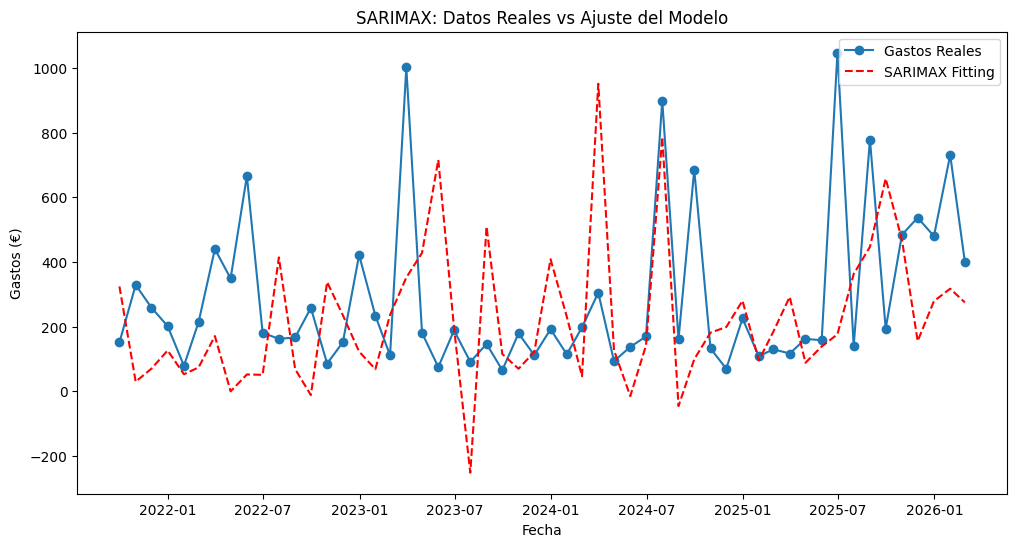

Error Absoluto Medio In-Sample: 223.48€


In [6]:
# Predecimos 'in-sample' (sobre los datos que ya tenemos)
predictions = sarimax_results.predict(start=ts_df.index[0], end=ts_df.index[-1], exog=exog)

plt.figure(figsize=(12, 6))
plt.plot(ts_df.index, y, label='Gastos Reales', marker='o')
plt.plot(ts_df.index, predictions, label='SARIMAX Fitting', color='red', linestyle='dashed')
plt.title('SARIMAX: Datos Reales vs Ajuste del Modelo')
plt.xlabel('Fecha')
plt.ylabel('Gastos (€)')
plt.legend()
plt.show()

print(f"Error Absoluto Medio In-Sample: {mean_absolute_error(y, predictions):.2f}€")

### 5. Diagnóstico Residuales
Este gráfico es vital en estadística. Mide que lo que tu modelo NO pudo adivinar (el error) parezca sólo "ruido blanco" y no siga un patrón oculto que te dejaste por fuera.

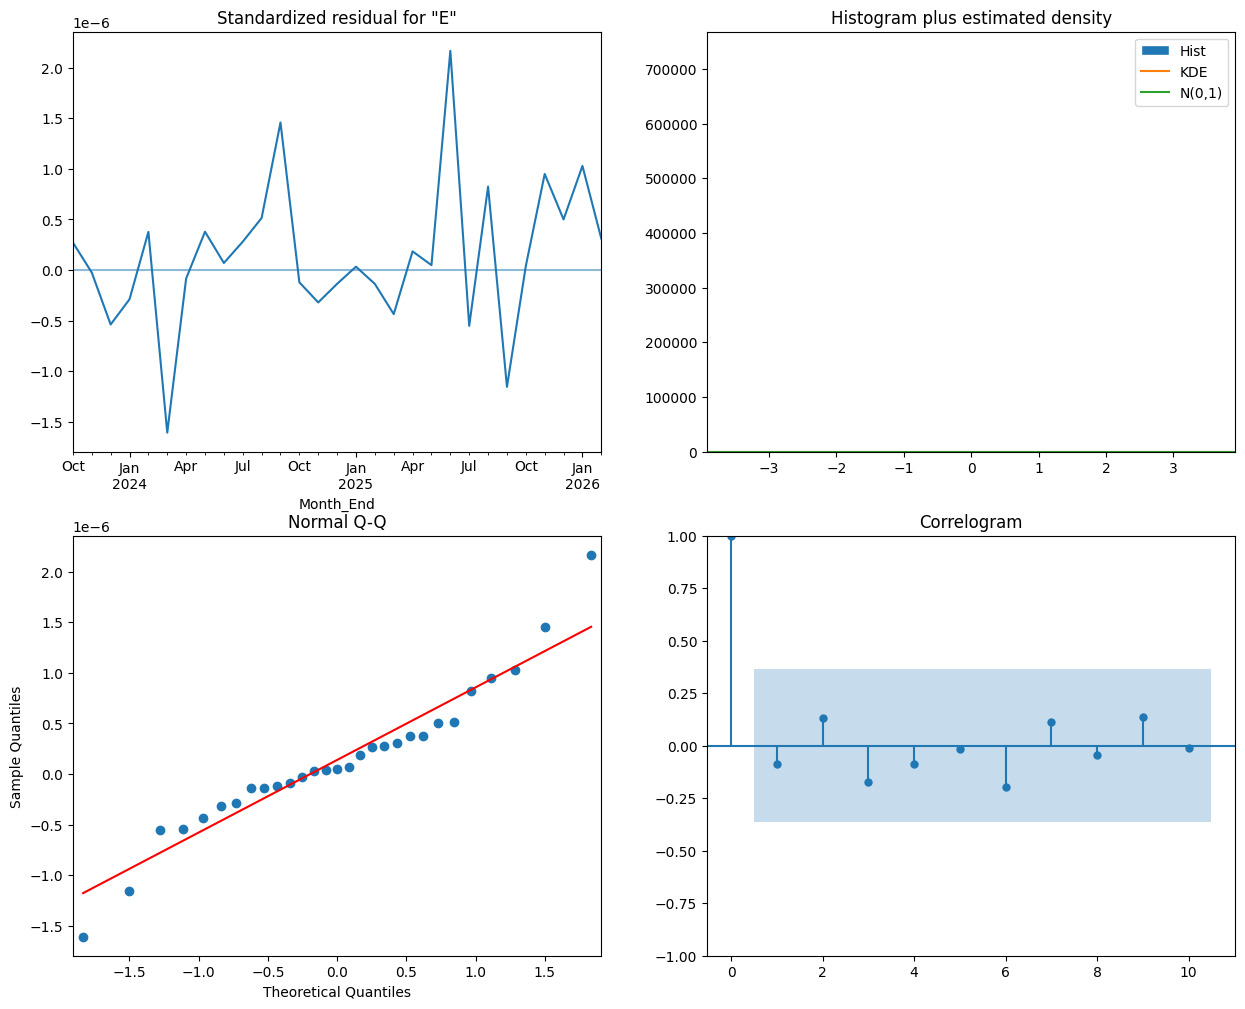

In [7]:
fig = sarimax_results.plot_diagnostics(figsize=(15, 12))
plt.show()